In [1]:
from fastbook import *
from duckduckgo_search import DDGS  
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

# call the function to download bird image
urls = search_images('bird photos', max_images=1)
urls[0]

/var/folders/qc/8f8k87s13ld9rf4lclv6h8n80000gn/T/ipykernel_7671/312186372.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')


'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=animal-avian-beak-326900.jpg&fm=jpg'

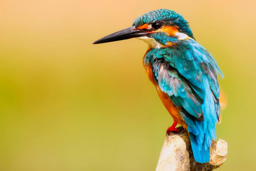

In [3]:
from fastdownload import download_url
dest = 'bird.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

/var/folders/qc/8f8k87s13ld9rf4lclv6h8n80000gn/T/ipykernel_7671/312186372.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')


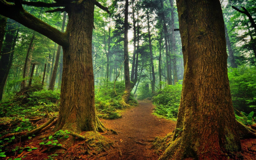

In [4]:
# call the function to download forest image
urls_forest = search_images('forest photos', max_images=1)
urls_forest[0]

# download it 
forest = 'forest.jpg'
download_url(urls_forest[0], forest, show_progress=False)

from fastai.vision.all import *
imf = Image.open(forest)
imf.to_thumb(256,256)

In [5]:
# now lets grab an image of bird and forest an put it in separate folder
searches = 'forest','bird'
path = Path('bird_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

/var/folders/qc/8f8k87s13ld9rf4lclv6h8n80000gn/T/ipykernel_7671/312186372.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
/var/folders/qc/8f8k87s13ld9rf4lclv6h8n80000gn/T/ipykernel_7671/312186372.py:5: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
/Users/sarvagra/Library/Python/3.9/lib/python/site-packages/fastai/vision/utils.py:80: ResourceWarning: unclosed file <_io.BufferedReader name='/Users/sarvagra/Desktop/Coding/websites-clones/bird_or_not/bird/0f0e83f9-9c8d-452b-a0d1-f98b08fa78a7.jpg'>
  if not verify_image(file): return
/Users/sarvagra/Library/Python/3.9/lib/python/site-packages/fastai/vision/utils.py:80: 

In [6]:
# delete the failed images 
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

/Users/sarvagra/Library/Python/3.9/lib/python/site-packages/fastcore/parallel.py:63: ResourceWarning: unclosed file <_io.BufferedReader name='/Users/sarvagra/Desktop/Coding/websites-clones/bird_or_not/bird/0f0e83f9-9c8d-452b-a0d1-f98b08fa78a7.jpg'>
  return g(item)
/Users/sarvagra/Library/Python/3.9/lib/python/site-packages/fastcore/parallel.py:63: ResourceWarning: unclosed file <_io.BufferedReader name='/Users/sarvagra/Desktop/Coding/websites-clones/bird_or_not/bird/908a4fba-70d8-4b95-bd3e-0435be84ec3a.jpg'>
  return g(item)


18

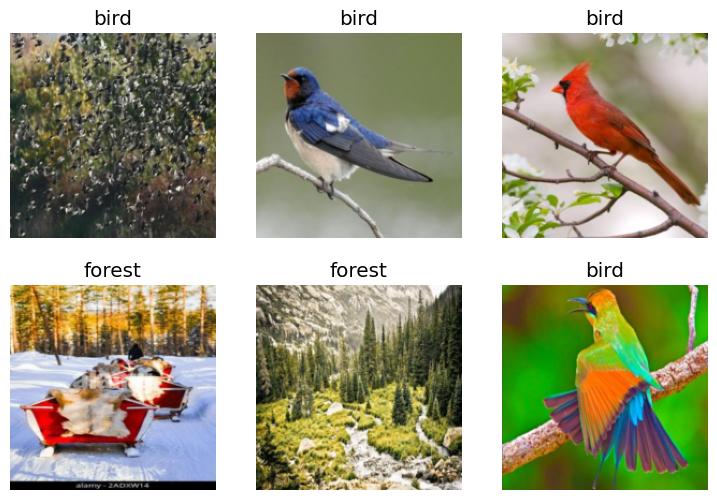

In [7]:
# split the data into train and validate 
# do not come and do this again after filtering data using image_classifier_cleaner !!
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=41),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

In [8]:
# train the latest model, on 5 epochs

learn = vision_learner(dls, resnet34, metrics=error_rate)

learn.fine_tune(5)

epoch,train_loss,valid_loss,error_rate,time
0,0.957066,0.257595,0.066667,00:05


epoch,train_loss,valid_loss,error_rate,time
0,0.299191,0.196670,0.083333,00:06
1,0.161215,0.133865,0.066667,00:06
2,0.111756,0.117335,0.033333,00:06
3,0.080324,0.137871,0.033333,00:06
4,0.063519,0.145405,0.033333,00:06


In [10]:
# test our model 
is_bird,_,probs = learn.predict(PILImage.create('rio.webp'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: bird.
Probability it's a bird: 0.9990


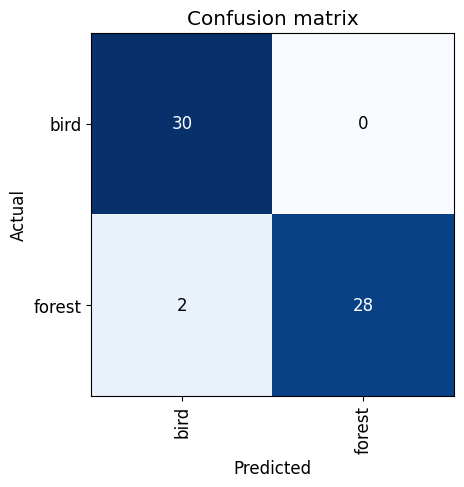

In [11]:
# confusion matrix 

interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()


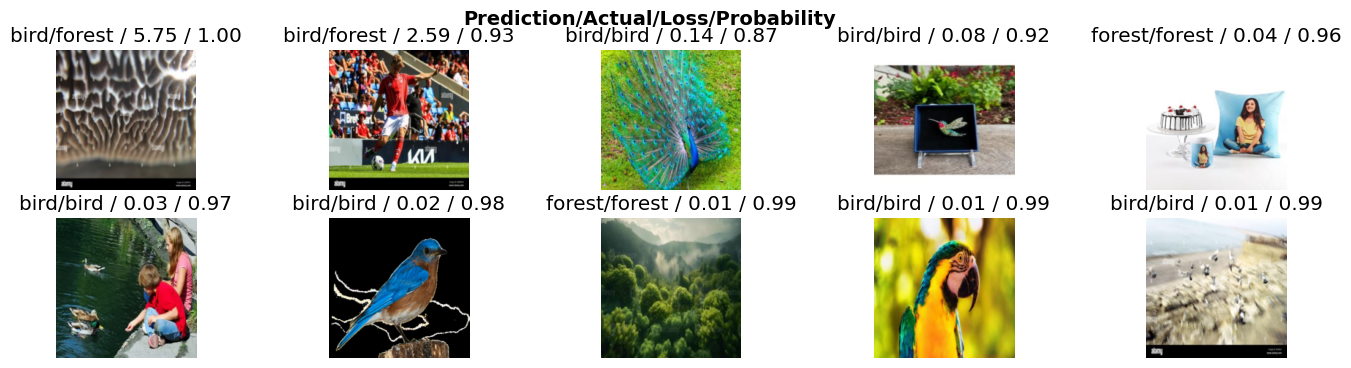

In [12]:
interp.plot_top_losses(10, nrows=2, figsize=(17,4))

In [13]:
# clean
from fastai.vision.widgets import ImageClassifierCleaner
cleaner = ImageClassifierCleaner(learn)
cleaner

In [14]:
# Once we have changed wether to delete or put in another category in the above cell, we run the below loop to delete or perform the category change 
for idx in cleaner.delete() : cleaner.fns[idx].unlink()         #delete the ones we want
for idx,cat in cleaner.change() : shutil.move(str(cleaner.fns[idx]), path/cat)         #change the category of the ones we want
print("finished removing and changing the files")


finished removing and changing the files


In [ ]:
# for mac  set fallback to 1 
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
# now train the model again on new data 
# first create the new datablock

dldrs =DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=41),
    get_y=parent_label,
    item_tfms=Resize(128),
    batch_tfms=aug_transforms(mult=2)
).dataloaders(path, bs=32)




# then create new dataloaders
dldrs=birds.dataloaders(path,bs=32)

Could not do one pass in your dataloader, there is something wrong in it. Please see the stack trace below:


NotImplementedError: The operator 'aten::_linalg_solve_ex.result' is not currently implemented for the MPS device. If you want this op to be considered for addition please comment on https://github.com/pytorch/pytorch/issues/141287 and mention use-case, that resulted in missing op as well as commit hash 2236df1770800ffea5697b11b0bb0d910b2e59e1. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.

In [ ]:
# saving a model 
learn.export('bird_vs_forest.pkl')